# Delivery ETA Prediction

## Dataset Audit

The raw delivery dataset is inspected to understand its size, columns, data types, missing values, duplicate rows, and initial value formats before any cleaning is applied.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.data import (
load_raw_data,
clean_delivery_data,
create_train_test_split,
)
from src.evaluate import calculate_regression_metrics
from src.features import create_features
from src.train import cross_validate_pipelines
from src.tuning import tune_model
import joblib

raw_df = load_raw_data()
raw_df.info()
display(raw_df.head())

print("=================================================================================")
print(raw_df.describe())
print("=================================================================================")
print(raw_df.columns)
print("=================================null================================================")
print(raw_df.isnull().sum())
print("=================================nan================================================")
print(raw_df.isna().sum())
print("===================================dup============================================")
print(raw_df.duplicated().sum())
print("===================================shape============================================")
print(raw_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  Vehicle_condition  
count                 45593.000000       45593.000000  
mean                     70.845702           1.023359  
std                      21.118812           0.839065  
min                       0.010000           0.000000  

## Target and Data Dictionary

The prediction target is `Time_taken(min)`, which records delivery duration in minutes. The data dictionary documents the meaning, type, unit, and modeling decision for every original column.

In [2]:
target = raw_df['Time_taken(min)']
print(target.head(3))
print(target.dtype)

data_dictionary = pd.DataFrame([
    ("ID", "Order identifier", "None", "Exclude: identifier"),
    ("Delivery_person_ID", "Courier identifier", "None", "Exclude: identifier"),
    ("Delivery_person_Age", "Courier age", "Years", "Predictor"),
    ("Delivery_person_Ratings", "Courier rating", "Score", "Predictor"),
    ("Restaurant_latitude", "Restaurant latitude", "Degrees", "Derive distance"),
    ("Restaurant_longitude", "Restaurant longitude", "Degrees", "Derive distance"),
    ("Delivery_location_latitude", "Customer latitude", "Degrees", "Derive distance"),
    ("Delivery_location_longitude", "Customer longitude", "Degrees", "Derive distance"),
    ("Order_Date", "Order date", "Date", "Derive date features"),
    ("Time_Orderd", "Order placement time", "Clock time", "Derive time features"),
    ("Time_Order_picked", "Courier pickup time", "Clock time", "Check availability/leakage"),
    ("Weatherconditions", "Weather condition", "Category", "Predictor"),
    ("Road_traffic_density", "Traffic level", "Category", "Predictor"),
    ("Vehicle_condition", "Vehicle condition level", "Ordinal", "Predictor"),
    ("Type_of_order", "Order category", "Category", "Predictor"),
    ("Type_of_vehicle", "Courier vehicle type", "Category", "Predictor"),
    ("multiple_deliveries", "Concurrent delivery count", "Count", "Predictor"),
    ("Festival", "Festival-day indicator", "Category", "Predictor"),
    ("City", "City category", "Category", "Predictor"),
    ("Time_taken(min)", "Observed delivery duration", "Minutes", "Target"),
], columns=["column", "meaning", "unit", "modeling_decision"])
data_dictionary.insert(2, "dtype", data_dictionary["column"].map(raw_df.dtypes.astype(str)))

display(data_dictionary)

0    (min) 24
1    (min) 33
2    (min) 26
Name: Time_taken(min), dtype: str
str


,column,meaning,dtype,unit,modeling_decision
0,ID,Order identifier,str,None,Exclude: identifier
1,Delivery_person_ID,Courier identifier,str,None,Exclude: identifier
2,Delivery_person_Age,Courier age,str,Years,Predictor
3,Delivery_person_Ratings,Courier rating,str,Score,Predictor
4,Restaurant_latitude,Restaurant latitude,float64,Degrees,Derive distance
5,Restaurant_longitude,Restaurant longitude,float64,Degrees,Derive distance
6,Delivery_location_latitude,Customer latitude,float64,Degrees,Derive distance
7,Delivery_location_longitude,Customer longitude,float64,Degrees,Derive distance
8,Order_Date,Order date,str,Date,Derive date features
9,Time_Orderd,Order placement time,str,Clock time,Derive time features


## Data Cleaning

The reusable cleaning process standardizes categories, converts numeric and time values, validates coordinates, handles missing values, and removes unusable rows. The raw dataset remains unchanged.

In [3]:
cleaned_df = clean_delivery_data(raw_df)

print("raw shape:", raw_df.shape)
print("cleaned shape:", cleaned_df.shape)
display(cleaned_df.head(3))
print(cleaned_df.isna().sum())
print("exact duplicates", raw_df.duplicated().sum())



raw shape: (45593, 20)
cleaned shape: (41953, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,0 days 11:30:00,0 days 11:45:00,Sunny,High,2,Snack,Motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,2,Snack,Scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,0,Drinks,Motorcycle,1.0,No,Urban,26


ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1809
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
dtype: int64
exact duplicates 0


## Feature Engineering

Two reproducible predictors are created before visualization: `distance_km` estimates straight-line delivery distance with the Haversine formula, and `order_hour` extracts the hour of day from the order time.

In [4]:
df_features = create_features(cleaned_df)
display(df_features.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,0 days 11:30:00,...,High,2,Snack,Motorcycle,0.0,No,Urban,24,3.025153,11.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,0 days 19:45:00,...,Jam,2,Snack,Scooter,1.0,No,Metropolitian,33,20.183558,19.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,0 days 08:30:00,...,Low,0,Drinks,Motorcycle,1.0,No,Urban,26,1.552760,8.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,0 days 18:00:00,...,Medium,0,Buffet,Motorcycle,1.0,No,Metropolitian,21,7.790412,18.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,0 days 13:30:00,...,High,1,Snack,Scooter,1.0,No,Metropolitian,30,6.210147,13.0


## Exploratory Data Analysis

The cleaned, feature-engineered data is visualized to understand the target distribution and its relationships with time, weather, traffic, and vehicle characteristics before model training.

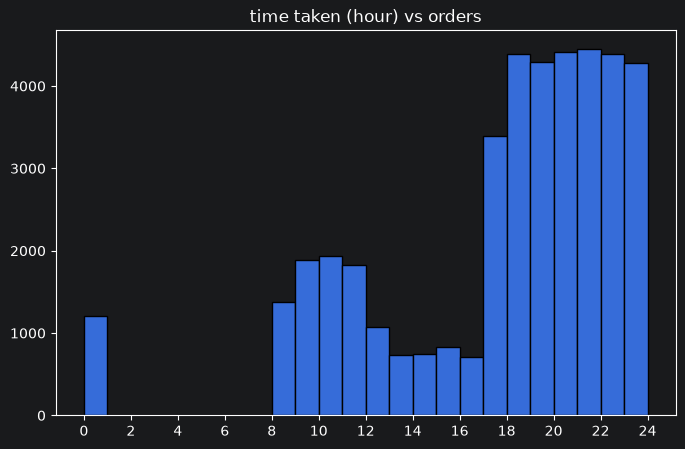

(41953, 20)


In [5]:
#time takeny

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
      cleaned_df["Time_Order_picked"].dt.total_seconds()/3600 ,
      bins=range(25),
      edgecolor="black"
  )
ax.set_title("time taken (hour) vs orders")
ax.set_xticks(range(0, 25, 2))
plt.show()
print(cleaned_df.shape)


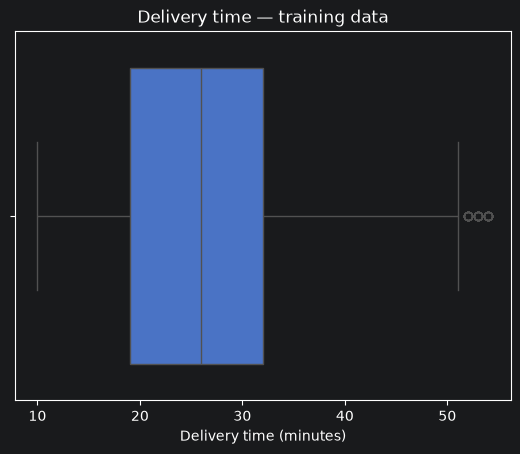

In [6]:
sns.boxplot(x=cleaned_df["Time_taken(min)"])

plt.title("Delivery time — training data")
plt.xlabel("Delivery time (minutes)")
plt.show()

### Delivery Time by Weather

The delivery-time distribution is compared across weather categories to identify shifts in typical duration, spread, and possible outliers.

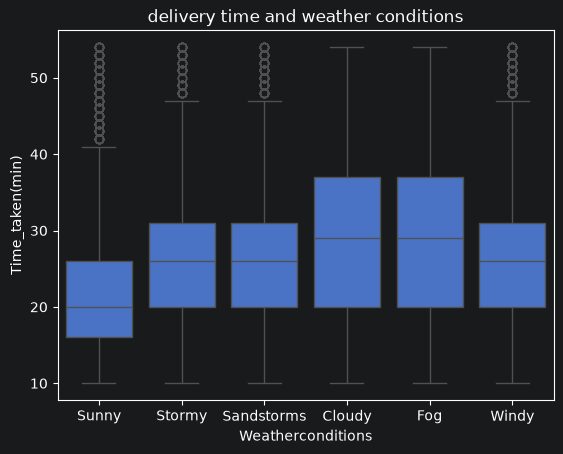

In [7]:

sns.boxplot(cleaned_df,y="Time_taken(min)", x="Weatherconditions")
plt.title("delivery time and weather conditions")
plt.show()


Sunny conditions contain some high delivery-time observations, but weather alone may not explain them. Distance, traffic, and other delivery conditions should be considered before interpreting these values as weather effects.

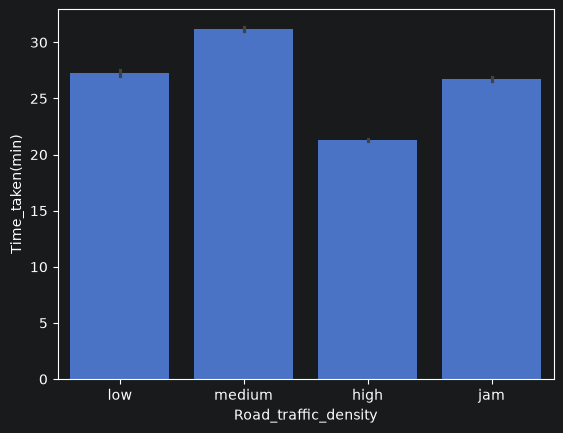

In [8]:
sns.barplot(
    data=cleaned_df,
    x="Road_traffic_density",
    y="Time_taken(min)",
)
plt.xticks([0,1,2,3], ["low", "medium", "high", "jam"])
plt.show()

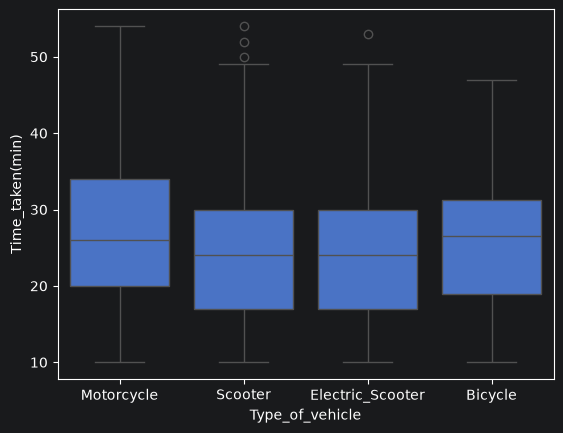

In [9]:
sns.boxplot(
    data=cleaned_df,
    x="Type_of_vehicle",
    y="Time_taken(min)",
)
plt.show()


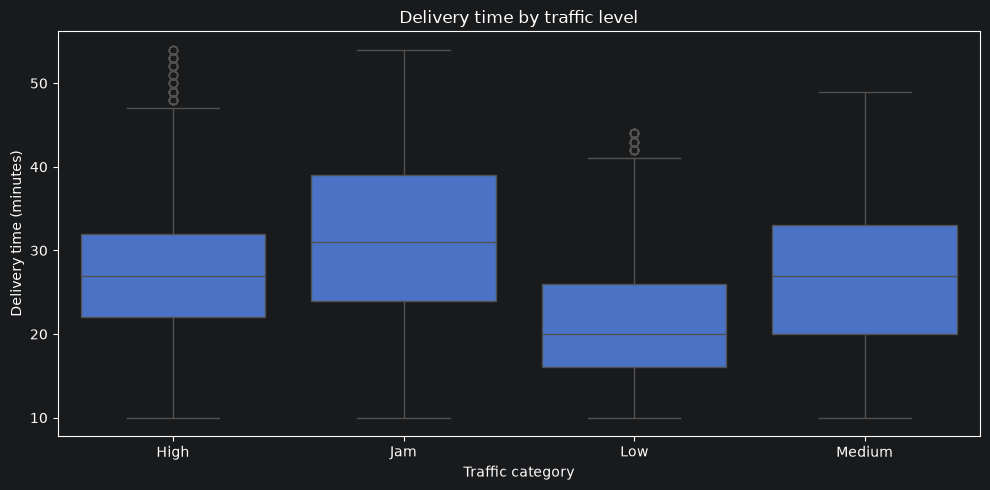

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=cleaned_df,
    x="Road_traffic_density",
    y="Time_taken(min)",
    ax=ax,
)

ax.set_title("Delivery time by traffic level")
ax.set_xlabel("Traffic category")
ax.set_ylabel("Delivery time (minutes)")

plt.tight_layout()
plt.show()

### Numeric Correlation

The correlation matrix includes every numeric feature. Traffic is temporarily mapped to ordered numbers for this EDA calculation only; model encoding remains inside the training pipeline. Correlation describes linear association and does not establish causation.

In [11]:
correlation_df = df_features.select_dtypes(include="number").copy()
correlation_df["Road_traffic_density"] = df_features["Road_traffic_density"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Jam": 3,
})
corr = correlation_df.corr()
display(corr)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Vehicle_condition,multiple_deliveries,Time_taken(min),distance_km,order_hour,Road_traffic_density
Delivery_person_Age,1.000000,-0.087583,0.005910,0.011163,0.005900,0.011151,0.000796,0.001108,0.000849,0.116682,0.298550,-0.001368,0.000850,0.000618
Delivery_person_Ratings,-0.087583,1.000000,0.000191,0.001841,-0.000506,0.000751,-0.062472,-0.051439,0.022560,-0.117292,-0.342681,-0.103980,-0.062965,-0.068556
Restaurant_latitude,0.005910,0.000191,1.000000,0.004645,0.999977,0.005120,0.010686,0.010967,0.000256,0.010515,0.012185,0.017533,0.011081,0.008548
Restaurant_longitude,0.011163,0.001841,0.004645,1.000000,0.004638,0.999945,0.000471,0.002537,0.003897,0.008958,0.006680,-0.001506,0.000367,0.006396
Delivery_location_latitude,0.005900,-0.000506,0.999977,0.004638,1.000000,0.005183,0.014536,0.014222,0.000316,0.011345,0.014335,0.024245,0.014948,0.009967
Delivery_location_longitude,0.011151,0.000751,0.005120,0.999945,0.005183,1.000000,0.006494,0.007624,0.003991,0.010260,0.010042,0.008983,0.006416,0.008617
Time_Orderd,0.000796,-0.062472,0.010686,0.000471,0.014536,0.006494,1.000000,0.799597,0.003990,0.065475,0.184612,0.574798,0.998366,0.243630
Time_Order_picked,0.001108,-0.051439,0.010967,0.002537,0.014222,0.007624,0.799597,1.000000,0.009800,0.073537,0.201616,0.485270,0.804079,0.314529
Vehicle_condition,0.000849,0.022560,0.000256,0.003897,0.000316,0.003991,0.003990,0.009800,1.000000,-0.098850,-0.235016,0.009025,0.003985,0.010951
multiple_deliveries,0.116682,-0.117292,0.010515,0.008958,0.011345,0.010260,0.065475,0.073537,-0.098850,1.000000,0.386747,0.123810,0.065761,0.160260


### Correlation Heatmap

The heatmap provides a visual summary of the numeric correlation values calculated above.

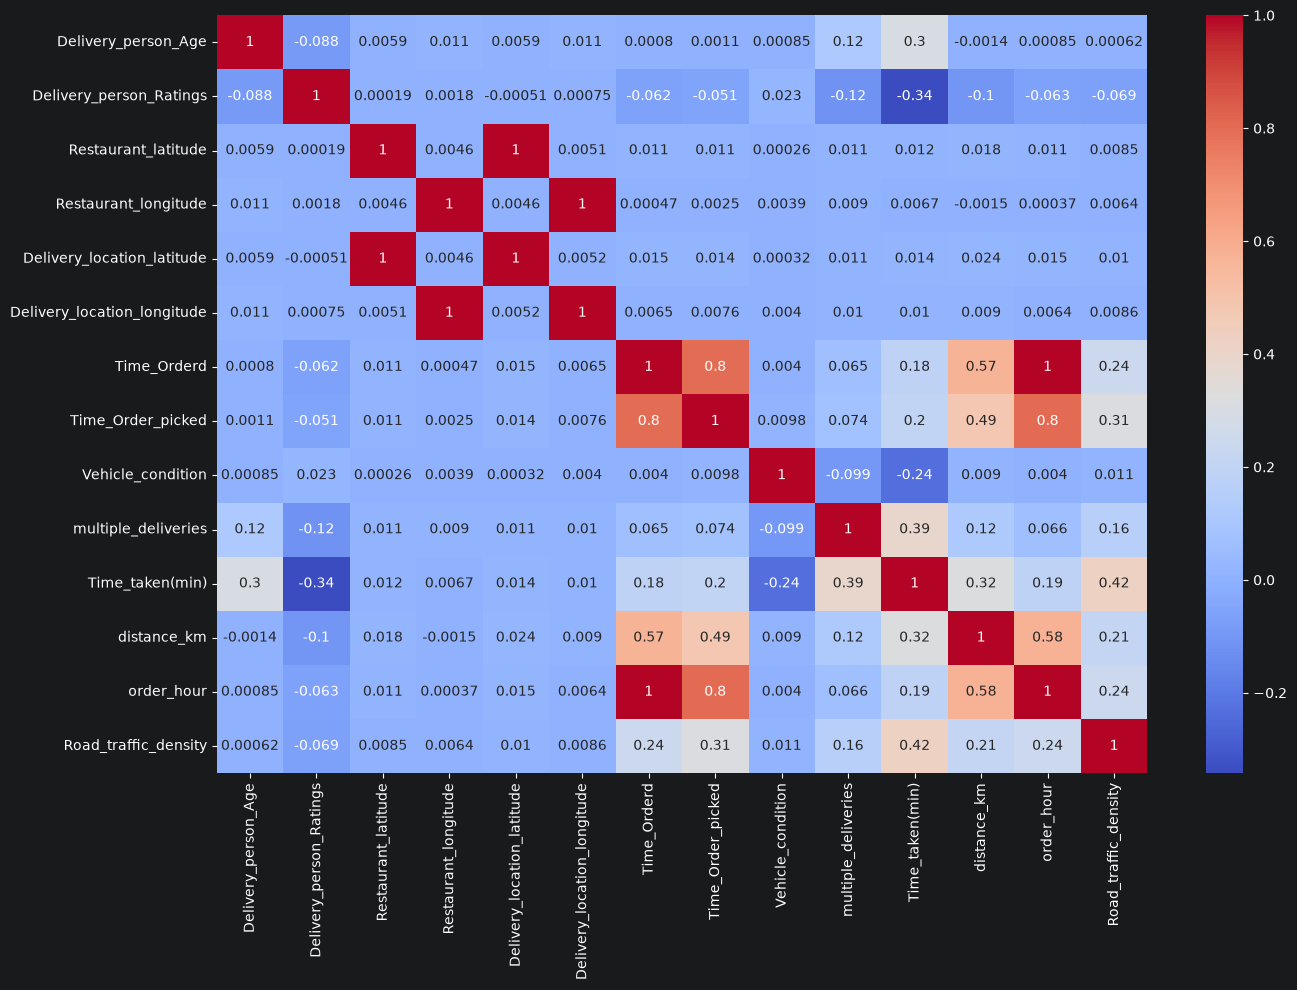

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()


Traffic density shows a positive relationship with delivery time, indicating that denser traffic is generally associated with longer deliveries. Other recorded factors must still be considered together during modeling.

### Delivery Time by Pickup Hour

Average delivery duration is examined across pickup hours to reveal time-of-day patterns that may reflect traffic intensity and order demand.

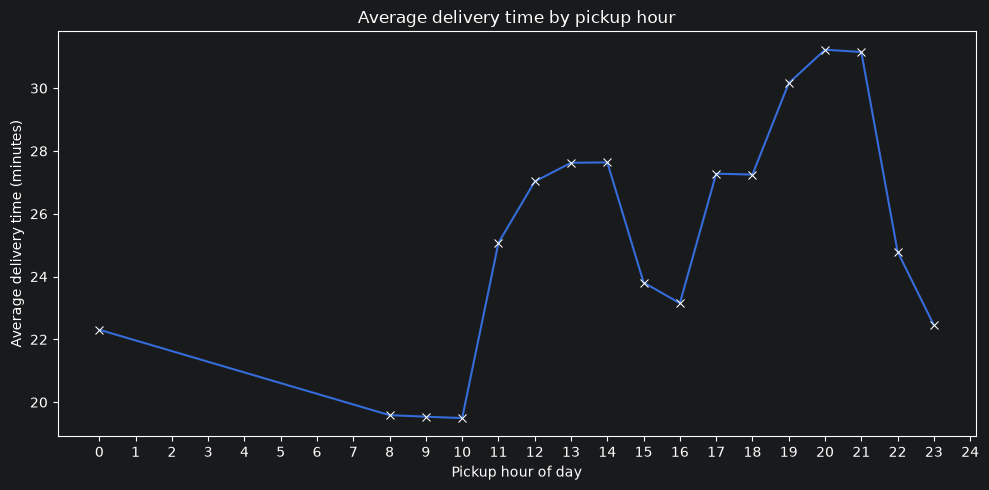

In [13]:
plot_df = cleaned_df.copy()

# Extract whole pickup hours from timedelta values.
plot_df["pickup_hour"] = (
    (plot_df["Time_Order_picked"].dt.total_seconds() // 3600) % 24
).astype("Int64")

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=plot_df,
    x="pickup_hour",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None,
    marker="x",
    ax=ax,
)



ax.set_title("Average delivery time by pickup hour")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Average delivery time (minutes)")
ax.set_xticks(range(25))
plt.tight_layout()
plt.show()

## Train/Test Split

The feature-engineered dataset is divided into an 80% training set and a 20% held-out test set. The training set is used for model comparison and tuning, while the test set remains reserved for the final evaluation.

In [14]:
print(df_features[
  [
      "distance_km",
      "Road_traffic_density",
      "order_hour",
      "Weatherconditions",
      "Type_of_vehicle",
      "Time_taken(min)",
  ]
].head())

X_train, X_test, y_train, y_test = create_train_test_split(cleaned_df)
print("xtrain:", X_train.shape)
print("xtest:", X_test.shape)
print("ytrain:", y_train.shape)
print("ytest:", y_test.shape)

   distance_km Road_traffic_density  order_hour Weatherconditions  \
0     3.025153                 High        11.0             Sunny   
1    20.183558                  Jam        19.0            Stormy   
2     1.552760                  Low         8.0        Sandstorms   
3     7.790412               Medium        18.0             Sunny   
4     6.210147                 High        13.0            Cloudy   

  Type_of_vehicle  Time_taken(min)  
0      Motorcycle               24  
1         Scooter               33  
2      Motorcycle               26  
3      Motorcycle               21  
4         Scooter               30  
xtrain: (33562, 19)
xtest: (8391, 19)
ytrain: (33562,)
ytest: (8391,)


## Model Comparison

The dummy baseline and four regression pipelines are compared using five-fold cross-validation on the training set. MAE is the primary selection metric because it expresses the average prediction error directly in minutes.

In [27]:
cv_results = cross_validate_pipelines(X_train, y_train)
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.sort_values("validation_mae")

display(cv_df)

,validation_mae,validation_mse,validation_rmse,validation_r2,training_mae,fit_time
hist_gradient_boosting,3.126221,15.369735,3.920273,0.826192,2.894789,4.359392
random_forest,3.203755,16.453165,4.056143,0.813949,1.186945,4.772051
decision_tree,4.173738,30.284397,5.503000,0.657545,-0.000000,0.724890
linear_regression,4.871506,37.162668,6.095903,0.579825,4.865765,0.522216
ridge_regression,4.871507,37.162554,6.095893,0.579826,4.865778,0.459840
dummy_baseline,7.584291,88.560439,9.410452,-0.001214,7.584292,0.485640


hist gradient boosting achieved the lowest validation MAE and outperformed the dummy baseline. The Decision Tree showed substantial overfitting because its training MAE was much lower than its validation MAE. Random Forest was therefore selected for hyperparameter tuning.

## Hyperparameter Optimization

Random Forest achieved the lowest cross-validation MAE and is selected for tuning. RandomizedSearchCV evaluates different Random Forest configurations using only the training set, with MAE used to select the best configuration.

In [16]:
random_forest_tune = tune_model("hist_gradient_boosting", X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [28]:
from sklearn.base import clone

before_pipeline = clone(random_forest_tune.estimator)
before_pipeline.fit(X_train.copy(), y_train)
after_pipeline = random_forest_tune.best_estimator_

prediction_metrics = {}

for model_name, fitted_pipeline in [
    ("Before tuning", before_pipeline),
    ("After tuning", after_pipeline),
]:
    number_of_features = fitted_pipeline[:-1].transform(X_train.copy()).shape[1]

    training_predictions = fitted_pipeline.predict(X_train.copy())
    test_predictions = fitted_pipeline.predict(X_test.copy())

    prediction_metrics[f"{model_name} — training"] = calculate_regression_metrics(
        y_train, training_predictions, number_of_features
    )
    prediction_metrics[f"{model_name} — test"] = calculate_regression_metrics(
        y_test, test_predictions, number_of_features
    )

tuning_comparison = pd.DataFrame.from_dict(
    prediction_metrics, orient="index"
)[["mae", "mse", "rmse", "r2"]]

display(tuning_comparison)


,mae,mse,rmse,r2
Before tuning — training,2.927886,13.297117,3.646521,0.849675
Before tuning — test,3.108873,15.266336,3.907216,0.822806
After tuning — training,2.775815,11.931182,3.454154,0.865117
After tuning — test,3.093605,15.154404,3.892866,0.824105


The tuned Random Forest improved validation MAE compared with the untuned configuration. Its validation R² also increased, indicating that the tuned model explains more variation in delivery duration.

## Tuned Model and Final Evaluation

The best configuration from the tuning search is used to predict the held-out test set. Predicted and actual delivery times are compared, followed by MAE, MSE, RMSE, and R² as the final performance measures.

In [29]:
best_pipeline = random_forest_tune.best_estimator_
test = random_forest_tune.best_estimator_.predict(X_test)
transformed_test = (
    best_pipeline[:-1]
    .transform(X_test)
)

n_features = transformed_test.shape[1]

comparison_df = pd.DataFrame({
    "actual_value": y_test,
    "predicted_value": test
})

comparison_df["error"] = comparison_df["actual_value"] - comparison_df["predicted_value"]
comparison_df["absolute_error"] = comparison_df["error"].abs()
display(comparison_df.head(10))

,actual_value,predicted_value,error,absolute_error
20657,21,27.282534,-6.282534,6.282534
17666,18,14.696825,3.303175,3.303175
4615,25,28.801090,-3.801090,3.801090
39337,24,23.059995,0.940005,0.940005
8357,40,37.103610,2.896390,2.896390
16497,20,24.727009,-4.727009,4.727009
7605,22,22.915343,-0.915343,0.915343
38582,15,22.376086,-7.376086,7.376086
17901,31,36.904568,-5.904568,5.904568
33236,20,20.106666,-0.106666,0.106666


In [30]:


print(n_features)
test_metrics = calculate_regression_metrics(y_test, test, n_features)
display(pd.DataFrame([test_metrics], index=["tuned_boost_algo"]))


29


,mae,mse,rmse,r2,adjusted r2
tuned_boost_algo,3.093605,15.154404,3.892866,0.824105,0.823495


The final model has an average test error of approximately 3.09 minutes. Its RMSE of approximately 3.89 minutes indicates that some predictions have larger errors. An R² of approximately 0.82 means the model explains about half of the variation in test delivery times.

Save the final model
i choosed the hist_gradient_boosting cuz it preforms the best stats with the higher R2 and mae , so i tune it to boost its prediction , unlucky didnt get much improvement.

In [33]:
joblib.dump(best_pipeline, "../models/delivery_eta_pipeline.joblib")
joblib.dump(best_pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"], "../models/scaler.joblib")


['../models/scaler.joblib']